<a href="https://colab.research.google.com/github/litlig/notebooks/blob/main/adam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of training samples: 60000
Number of test samples: 10000


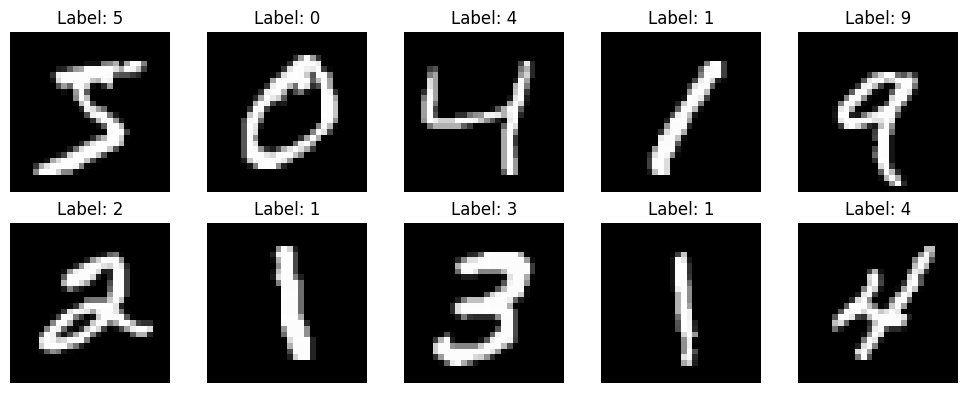

In [25]:

#@title Load dataset
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Download MNIST
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
print(f"Number of training samples: {len(train_data)}")
print(f"Number of test samples: {len(test_data)}")

# Show first 10 samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_data[i]

    # Fix: Squeeze the channel dimension and convert to numpy for imshow
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

to_tensor = transforms.ToTensor()
# Define data loaders for mini-batch training
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [46]:
[i for i in range(2)]

[0, 1]

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import collections # Import collections for defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 28*28
dim_hidden = 128
lr = 0.001
n_epoch = 1 # how many epoch we train for


class MLPLayer(nn.Module):
  def __init__(self, input_dim, hidden_dim):
    super(MLPLayer, self).__init__()
    self.linear = nn.Linear(input_dim, hidden_dim)
    self.activation = nn.Sigmoid()

  def forward(self, x):
    return self.activation(self.linear(x))


class SimpleNN(nn.Module):
    def __init__(self, n_layer):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential()
        self.mlp.append(MLPLayer(input_dim, dim_hidden))
        for _ in range(n_layer - 1):
            self.mlp.append(MLPLayer(dim_hidden, dim_hidden))
        self.mlp.append(nn.Linear(dim_hidden, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.mlp(x)
        return x

mlp_model = SimpleNN(n_layer=3).to(device)
print(mlp_model)
def train(model, optimizer):
    model.train()
    optimizer = optimizer
    step_count = 0
    epoch = 0
    losses = []
    # Use defaultdict to automatically create a list for each new key
    all_grad_norms = collections.defaultdict(list)

    for epoch in range(n_epoch):
        epoch += 1
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = nn.CrossEntropyLoss()(output, target)
            losses.append(loss.item())
            loss.backward()

            # Record L2 norm of gradients after backward pass for all parameters
            for name, param in model.named_parameters():
                if param.grad is not None:
                    all_grad_norms[name].append(param.grad.norm().item())

            optimizer.step()
            step_count += 1

    print(f"Training finished after {step_count} steps.")
    print(f"Number of gradient norm series collected: {len(all_grad_norms)}") # Diagnostic print
    return losses, all_grad_norms

mlp_losses, mlp_grad = train(mlp_model, optimizer=optim.SGD(mlp_model.parameters(), lr=lr))

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (mlp): Sequential(
    (0): MLPLayer(
      (linear): Linear(in_features=784, out_features=128, bias=True)
      (activation): Sigmoid()
    )
    (1): MLPLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
      (activation): Sigmoid()
    )
    (2): MLPLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
      (activation): Sigmoid()
    )
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Training finished after 938 steps.
Number of gradient norm series collected: 8


In [83]:
class AdamOptimizer(torch.optim.Optimizer):
  def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
      defaults = dict(lr=lr, betas=betas, eps=eps)
      super(AdamOptimizer, self).__init__(params, defaults)


  @torch.no_grad()
  def step(self, closure=None):
      loss = None
      if closure is not None:
          with torch.enable_grad():
              loss = closure()

      for group in self.param_groups:
          lr = group["lr"]
          for p in group["params"]:
              if p.grad is None:
                  continue
              grad = p.grad
              state = self.state[p]             # per-param persistent state

              if len(state) == 0:
                  state["step"] = 0
                  state["momentum"] = torch.zeros_like(p)
                  state["momentum_square"] = torch.zeros_like(p)

              state["step"] += 1
              buf = state["momentum"]
              buf.mul_(group["betas"][0]).add_(grad, alpha=1 - group["betas"][0])
              buf2 = state["momentum_square"]
              buf2.mul_(group["betas"][1]).add_(grad * grad, alpha=1 - group["betas"][1])
              signal = buf / (1 - group["betas"][0] ** state["step"])
              noise = buf2 / (1 - group["betas"][1] ** state["step"])
              update = signal / (noise**0.5 + group["eps"])
              p.add_(update, alpha=-lr)

      return loss

In [82]:
a.param_groups[0].keys()

dict_keys(['params', 'lr', 'betas', 'eps'])

In [87]:
adam_model = SimpleNN(n_layer=3).to(device)
adam_losses, adam_grad = train(adam_model, optimizer=AdamOptimizer(adam_model.parameters(), lr=lr))

Training finished after 938 steps.
Number of gradient norm series collected: 8


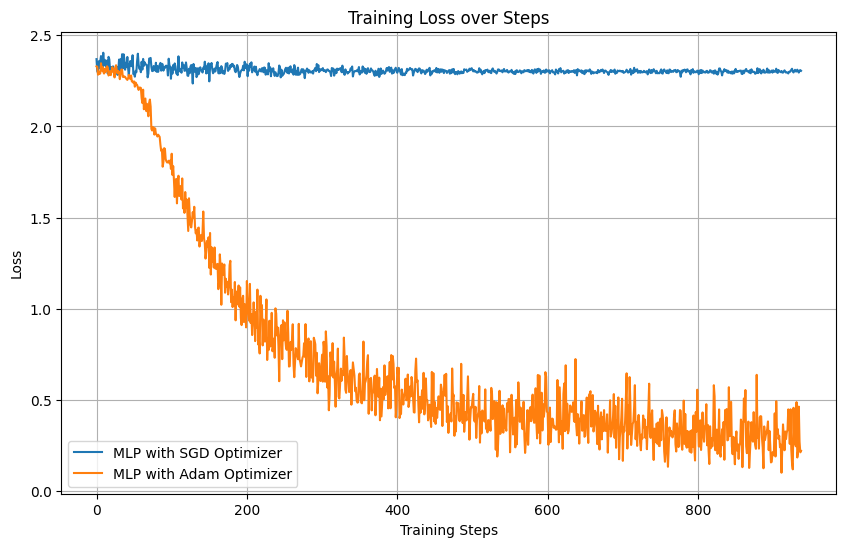

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(mlp_losses, label="MLP with SGD Optimizer")
plt.plot(adam_losses, label="MLP with Adam Optimizer")
plt.title("Training Loss over Steps")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

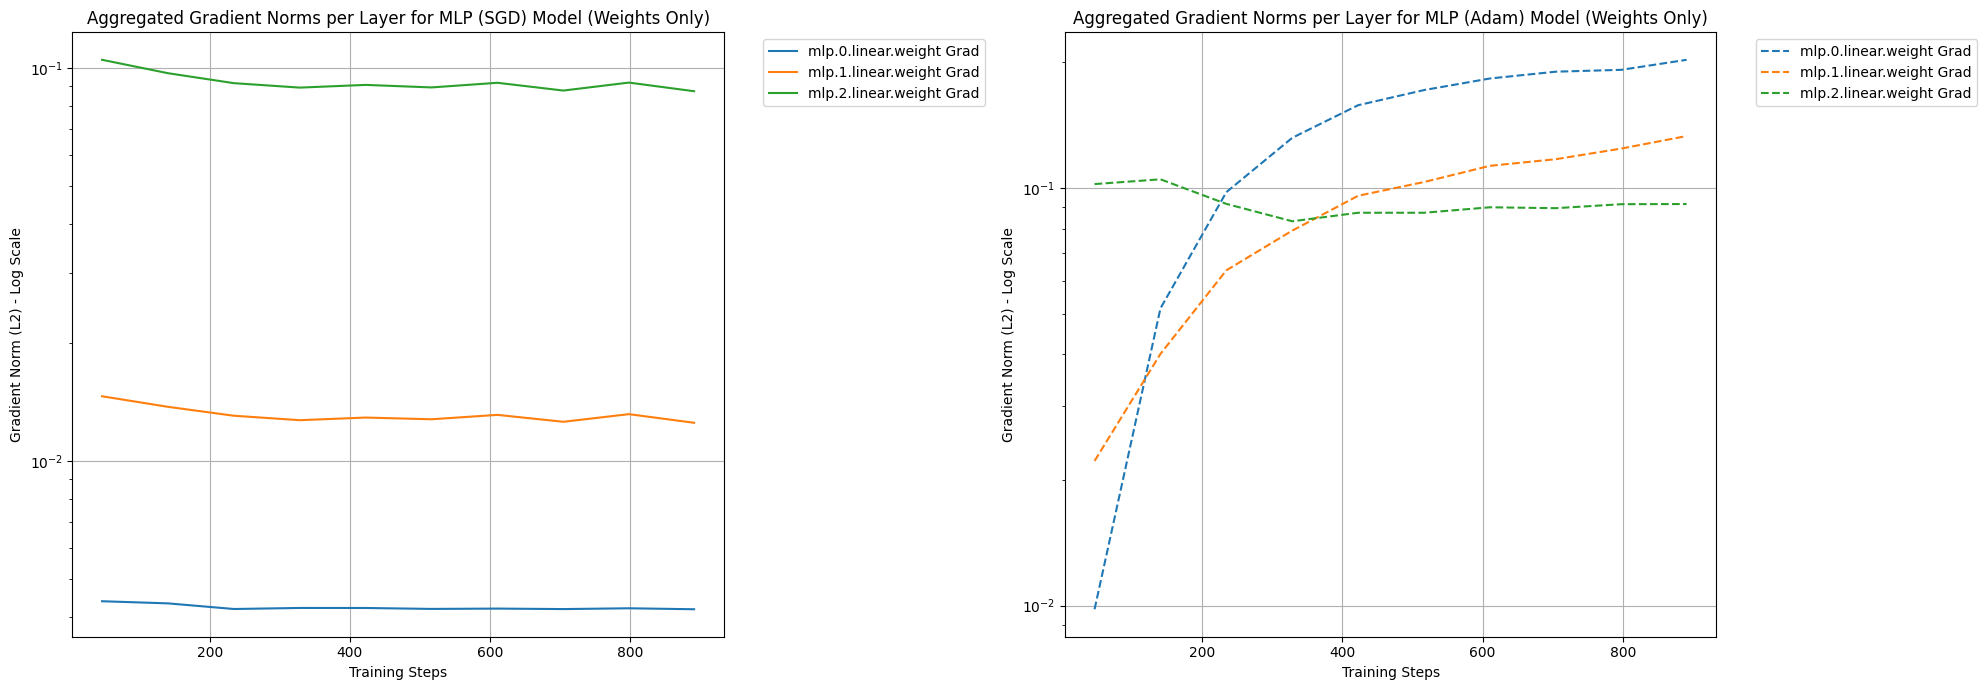

In [53]:
import matplotlib.pyplot as plt
import numpy as np

def aggregate_data(data_list, num_points=10):
    if not data_list:
        return [], []
    data_array = np.array(data_list)
    # Use np.array_split to divide the data into approximately equal parts
    split_arrays = np.array_split(data_array, num_points)
    aggregated_means = [np.mean(arr) for arr in split_arrays if len(arr) > 0]

    # Generate corresponding x-values for the aggregated points
    # We'll use the approximate midpoint of each original segment for the x-axis
    original_indices = np.arange(len(data_list))
    split_indices = np.array_split(original_indices, num_points)
    aggregated_x = [np.mean(arr) for arr in split_indices if len(arr) > 0]

    return aggregated_x, aggregated_means


fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # Create two subplots side-by-side

# Plotting gradients for MLP model (SGD) on the first subplot
axes[0].set_title("Aggregated Gradient Norms per Layer for MLP (SGD) Model (Weights Only)")
for name, grad_norms_list in mlp_grad.items():
    if 'linear.weight' in name: # Filter for weights only
        aggregated_x, aggregated_y = aggregate_data(grad_norms_list, 10)
        axes[0].plot(aggregated_x, aggregated_y, label=f'{name} Grad')
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("Gradient Norm (L2) - Log Scale")
axes[0].set_yscale('log') # Set y-axis to log scale
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True)

# Plotting gradients for Adam model on the second subplot
axes[1].set_title("Aggregated Gradient Norms per Layer for MLP (Adam) Model (Weights Only)")
for name, grad_norms_list in adam_grad.items():
    if 'linear.weight' in name: # Filter for weights only
        aggregated_x, aggregated_y = aggregate_data(grad_norms_list, 10)
        axes[1].plot(aggregated_x, aggregated_y, label=f'{name} Grad', linestyle='--')
axes[1].set_xlabel("Training Steps")
axes[1].set_ylabel("Gradient Norm (L2) - Log Scale")
axes[1].set_yscale('log') # Set y-axis to log scale
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True)

plt.tight_layout()
plt.show()